:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`plot_02_glm_demo.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings

# Ignore the first specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Ignore the second specific warning
warnings.filterwarnings(
    "ignore",
    message="Ignoring cached namespace 'core'",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=(
        "invalid value encountered in div "
    ),
    category=RuntimeWarning,
)

# GLM Demo: Toy Model Examples

:::{warning}
This demonstration is currently in its alpha stage. It presents various regularization techniques on
GLMs trained on a Gaussian noise stimuli, and a minimal example of fitting and simulating a pair of coupled
neurons. More work needs to be done to properly compare the performance of the regularization strategies on
realistic simulations and real neural recordings.
:::

## Introduction

In this demo we will work through two toy examples of a Poisson-GLM on synthetic data: a purely feed-forward input model
and a recurrently coupled model.

In particular, we will learn how to:

- Define & configurate a GLM object.
- Fit the model
- Cross-validate the model with `sklearn`
- Simulate spike trains.

Before digging into the GLM module, let's first import the packages
 we are going to use for this tutorial, and generate some synthetic
 data.

In [2]:
import jax
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from sklearn import model_selection

import nemos as nmo

np.random.seed(111)
# random design tensor. Shape (n_time_points, n_features).
X = 0.5*np.random.normal(size=(100, 5))

# log-rates & weights, shape (1, ) and (n_features, ) respectively.
b_true = np.zeros((1, ))
w_true = np.random.normal(size=(5, ))

# sparsify weights
w_true[1:4] = 0.

# generate counts
rate = jax.numpy.exp(jax.numpy.einsum("k,tk->t", w_true, X) + b_true)
spikes = np.random.poisson(rate)

## The Feed-Forward GLM

### Model Definition
The class implementing the  feed-forward GLM is [`nemos.glm.GLM`](nemos.glm.GLM).
In order to define the class, one **must** provide:

- **Observation Model**: The observation model for the GLM, e.g. an object of the class of type
[`nemos.observation_models.Observations`](nemos.observation_models.Observations). So far, only the [`PoissonObservations`](nemos.observation_models.PoissonObservations)
model has been implemented.
- **Regularizer**: The desired regularizer, e.g. an object of the [`nemos.regularizer.Regularizer`](nemos.regularizer.Regularizer) class.
Currently, we implemented the un-regularized, Ridge, Lasso, and Group-Lasso regularization.

The default for the GLM class is the [`PoissonObservations`](nemos.observation_models.PoissonObservations) with log-link function with a Ridge regularization.
Here is how to define the model.

In [3]:
# default Poisson GLM with Ridge regularization and Poisson observation model.
model = nmo.glm.GLM()

print("Regularization type:     ", type(model.regularizer))
print("Observation model:", type(model.observation_model))

Regularization type:      <class 'nemos.regularizer.UnRegularized'>
Observation model: <class 'nemos.observation_models.PoissonObservations'>


### Model Configuration
One could visualize the model hyperparameters by calling [`get_params`](nemos.glm.GLM.get_params) method.

In [4]:
# get the glm model parameters only
print("\nGLM model parameters:")
for key, value in model.get_params(deep=False).items():
    print(f"\t- {key}: {value}")

# get the glm model parameters, including the all the
# attributes
print("\nNested parameters:")
for key, value in model.get_params(deep=True).items():
    if key in model.get_params(deep=False):
        continue
    print(f"\t- {key}: {value}")


GLM model parameters:
	- inverse_link_function: <function exp at 0x7f05fba10c20>
	- observation_model: PoissonObservations()
	- regularizer: UnRegularized()
	- regularizer_strength: None
	- solver_kwargs: {}
	- solver_name: LBFGS

Nested parameters:


These parameters can be configured at initialization and/or
set after the model is initialized with the following syntax:

In [5]:
# Poisson GLM with soft-plus NL
model = nmo.glm.GLM(
    observation_model="Poisson",
    inverse_link_function=jax.nn.softplus,
    solver_name="LBFGS",
    solver_kwargs={"tol":10**-10},
)

print("Regularizer type:      ", type(model.regularizer))
print("Observation model:", type(model.observation_model))

Regularizer type:       <class 'nemos.regularizer.UnRegularized'>
Observation model: <class 'nemos.observation_models.PoissonObservations'>


Hyperparameters can be set at any moment via the [`set_params`](nemos.glm.GLM.set_params) method.

In [6]:
model.set_params(
    regularizer=nmo.regularizer.Lasso(),
    inverse_link_function=jax.numpy.exp
)

print("Updated regularizer: ", model.regularizer)
print("Updated NL: ", model.inverse_link_function)

Updated regularizer:  Lasso()
Updated NL:  <PjitFunction of <function exp at 0x7f062f0354e0>>


/home/jenkins/agent/workspace/CCN_nemos_PR-612/venv/lib/python3.12/site-packages/nemos/base_class.py:83: UserWarning: Solver ``LBFGS`` is not allowed for regularizer Lasso(). Overriding solver with the default allowed solver ProximalGradient.
  setattr(self, key, value)


:::{warning}
Each [`Regularizer`](regularizers) has an associated attribute [`Regularizer.allowed_solvers`](nemos.regularizer.Regularizer.allowed_solvers)
which lists the optimizers that are suited for each optimization problem.
For example, a [`Ridge`](nemos.regularizer.Ridge) is differentiable and can be fit with `GradientDescent`
, `BFGS`, etc., while a [`Lasso`](nemos.regularizer.Lasso) should use the `ProximalGradient` method instead.
If the provided `solver_name` is not listed in the `allowed_solvers` this will raise an
exception.
:::



### Model Fit
Fitting the model is as straight forward as calling the `model.fit`
providing the design tensor and the population counts.
Additionally one may provide an initial parameter guess.
The same exact syntax works for any configuration.

In [7]:
# fit a ridge regression Poisson GLM
model = nmo.glm.GLM(regularizer="Ridge", regularizer_strength=0.1)
model.fit(X, spikes)

print("Ridge results")
print("True weights:      ", w_true)
print("Recovered weights: ", model.coef_)

Ridge results
True weights:       [0.49429818 0.         0.         0.         0.32923678]
Recovered weights:  [ 0.58121854  0.0082906   0.12080209 -0.03249488  0.253943  ]


(k-fold-selection)=
## K-fold Cross Validation with `sklearn`
Our implementation follows the `scikit-learn` api,  this enables us
to take advantage of the `scikit-learn` tool-box seamlessly, while at the same time
we take advantage of the `jax` GPU acceleration and auto-differentiation in the
back-end.

Here is an example of how we can perform 5-fold cross-validation via `scikit-learn`.

**Ridge**

In [8]:
parameter_grid = {"regularizer_strength": np.logspace(-1.5, 1.5, 6)}
# in practice, you should use more folds than 2, but for the purposes of this
# demo, 2 is sufficient.
cls = model_selection.GridSearchCV(model, parameter_grid, cv=2)
cls.fit(X, spikes)

print("Ridge results        ")
print("Best hyperparameter: ", cls.best_params_)
print("True weights:      ", w_true)
print("Recovered weights: ", cls.best_estimator_.coef_)

Ridge results        
Best hyperparameter:  {'regularizer_strength': np.float64(0.03162277660168379)}
True weights:       [0.49429818 0.         0.         0.         0.32923678]
Recovered weights:  [7.2912592e-01 1.6413178e-02 1.4818655e-01 1.8600374e-05 3.2897869e-01]


We can compare the Ridge cross-validated results with other regularization schemes.

**Lasso**

In [9]:
model.set_params(regularizer=nmo.regularizer.Lasso(), solver_name="ProximalGradient")
cls = model_selection.GridSearchCV(model, parameter_grid, cv=2)
cls.fit(X, spikes)

print("Lasso results        ")
print("Best hyperparameter: ", cls.best_params_)
print("True weights:      ", w_true)
print("Recovered weights: ", cls.best_estimator_.coef_)

Lasso results        
Best hyperparameter:  {'regularizer_strength': np.float64(0.03162277660168379)}
True weights:       [0.49429818 0.         0.         0.         0.32923678]
Recovered weights:  [ 0.6955168   0.          0.02943178 -0.          0.23854369]


**Group Lasso**

In [10]:
# define groups by masking. Mask size (n_groups, n_features)
mask = np.zeros((2, 5))
mask[0, [0, -1]] = 1
mask[1, 1:-1] = 1

regularizer = nmo.regularizer.GroupLasso(mask=mask)
model.set_params(regularizer=regularizer, solver_name="ProximalGradient")
cls = model_selection.GridSearchCV(model, parameter_grid, cv=2)
cls.fit(X, spikes)

print("\nGroup Lasso results")
print("Group mask:          :")
print(mask)
print("Best hyperparameter: ", cls.best_params_)
print("True weights:      ", w_true)
print("Recovered weights: ", cls.best_estimator_.coef_)


Group Lasso results
Group mask:          :
[[1. 0. 0. 0. 1.]
 [0. 1. 1. 1. 0.]]
Best hyperparameter:  {'regularizer_strength': np.float64(0.03162277660168379)}
True weights:       [0.49429818 0.         0.         0.         0.32923678]
Recovered weights:  [ 0.66614026  0.          0.         -0.          0.2843489 ]


## Simulate Spikes
We can generate spikes in response to a feedforward-stimuli
through the `model.simulate` method.

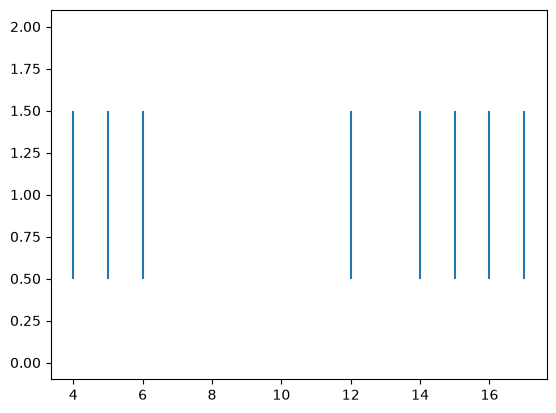

In [11]:
# here we are creating a new data input, of 20 timepoints (arbitrary)
# with the same number of features (mandatory)
Xnew = np.random.normal(size=(20, ) + X.shape[1:])
# generate a random key given a seed
random_key = jax.random.key(123)
spikes, rates = model.simulate(random_key, Xnew)

plt.figure()
plt.eventplot(np.where(spikes)[0])

## Simulate a Recurrently Coupled Network
In this section, we will show you how to generate spikes from a population; We assume that the coupling
filters are known or inferred.

:::{warning}

Making sure that the dynamics of your recurrent neural network are stable is non-trivial[$^{[1]}$](#ref-1). In particular,
coupling weights obtained by fitting a GLM by maximum-likelihood can generate unstable dynamics. If the
dynamics of your recurrently coupled model are unstable, you can try a `soft-plus` non-linearity
instead of an exponential, and you can "shrink" your weights until stability is reached.
:::

In [12]:
# Neural population parameters
n_neurons = 2
coupling_filter_duration = 100

Let's define the coupling filters that we will use to simulate
the pairwise interactions between the neurons. We will model the
filters as a difference of two Gamma probability density function.
The negative component will capture inhibitory effects such as the
refractory period of a neuron, while the positive component will
describe excitation.

In [13]:
np.random.seed(101)

# Gamma parameter for the inhibitory component of the filter
inhib_a = 1
inhib_b = 1

# Gamma parameters for the excitatory component of the filter
excit_a = np.random.uniform(1.1, 5, size=(n_neurons, n_neurons))
excit_b = np.random.uniform(1.1, 5, size=(n_neurons, n_neurons))

# define 2x2 coupling filters of the specific with create_temporal_filter
coupling_filter_bank = np.zeros((coupling_filter_duration, n_neurons, n_neurons))
for unit_i in range(n_neurons):
    for unit_j in range(n_neurons):
        coupling_filter_bank[:, unit_i, unit_j] = nmo.simulation.difference_of_gammas(
            coupling_filter_duration,
            inhib_a=inhib_a,
            excit_a=excit_a[unit_i, unit_j],
            inhib_b=inhib_b,
            excit_b=excit_b[unit_i, unit_j],
        )

# shrink the filters for simulation stability
coupling_filter_bank *= 0.8

# define a basis function
n_basis_funcs = 20
basis = nmo.basis.RaisedCosineLogEval(n_basis_funcs)

# approximate the coupling filters in terms of the basis function
_, coupling_basis = basis.evaluate_on_grid(coupling_filter_bank.shape[0])
coupling_coeff = nmo.simulation.regress_filter(coupling_filter_bank, coupling_basis)
intercept = -4 * np.ones(n_neurons)

We can check that our approximation worked by plotting the original filters
and the basis expansion

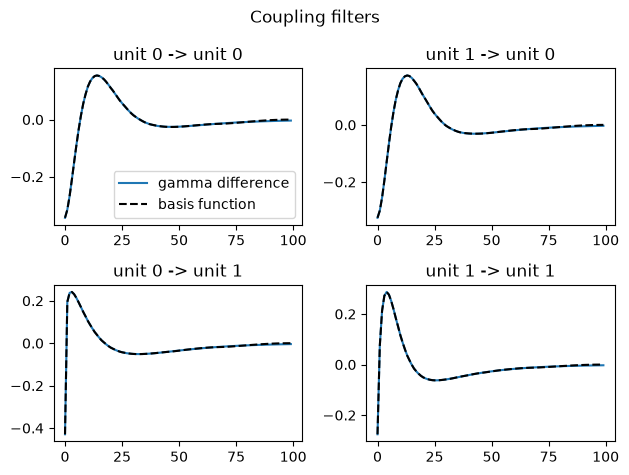

In [14]:
# plot coupling functions
n_basis_coupling = coupling_basis.shape[1]
fig, axs = plt.subplots(n_neurons, n_neurons)
plt.suptitle("Coupling filters")
for unit_i in range(n_neurons):
    for unit_j in range(n_neurons):
        axs[unit_i, unit_j].set_title(f"unit {unit_j} -> unit {unit_i}")
        coeff = coupling_coeff[unit_i, unit_j]
        axs[unit_i, unit_j].plot(coupling_filter_bank[:, unit_i, unit_j], label="gamma difference")
        axs[unit_i, unit_j].plot(np.dot(coupling_basis, coeff), ls="--", color="k", label="basis function")
axs[0, 0].legend()
plt.tight_layout()

Define a squared stimulus current for the first neuron, and no stimulus for
the second neuron

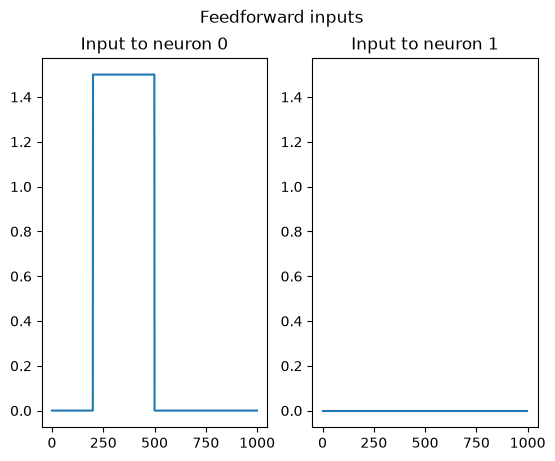

In [15]:
# define a squared current parameters
simulation_duration = 1000
stimulus_onset = 200
stimulus_offset = 500
stimulus_intensity = 1.5

# create the input tensor of shape (n_samples, n_neurons, n_dimension_stimuli)
feedforward_input = np.zeros((simulation_duration, n_neurons, 1))

# inject square input to the first neuron only
feedforward_input[stimulus_onset: stimulus_offset, 0] = stimulus_intensity

# plot the input
fig, axs = plt.subplots(1,2)
plt.suptitle("Feedforward inputs")
axs[0].set_title("Input to neuron 0")
axs[0].plot(feedforward_input[:, 0])

axs[1].set_title("Input to neuron 1")
axs[1].plot(feedforward_input[:, 1])
axs[1].set_ylim(axs[0].get_ylim())


# the input for the simulation will be the dot product
# of input_coeff with the feedforward_input
input_coeff = np.ones((n_neurons, 1))


# initialize the spikes for the recurrent simulation
init_spikes = np.zeros((coupling_filter_duration, n_neurons))

We can now simulate spikes by calling the `simulate_recurrent` function for the `nemos.simulate` module.

In [16]:
# call simulate, with both the recurrent coupling
# and the input
spikes, rates = nmo.simulation.simulate_recurrent(
    coupling_coef=coupling_coeff,
    feedforward_coef=input_coeff,
    intercepts=intercept,
    random_key=jax.random.key(123),
    feedforward_input=feedforward_input,
    coupling_basis_matrix=coupling_basis,
    init_y=init_spikes
)

And finally plot the results for both neurons.

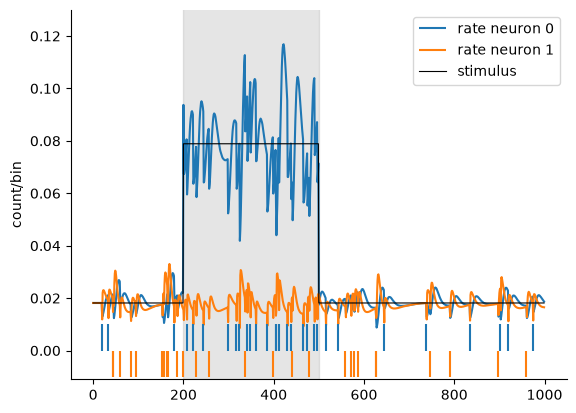

In [17]:
# mkdocs_gallery_thumbnail_number = 4
fig = plt.figure()
ax = plt.subplot(111)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

patch = Rectangle((200, -0.011), 300, 0.15,  alpha=0.2, color="grey")

p0, = plt.plot(rates[:, 0])
p1, = plt.plot(rates[:, 1])

plt.vlines(np.where(spikes[:, 0])[0], 0.00, 0.01, color=p0.get_color(), label="rate neuron 0")
plt.vlines(np.where(spikes[:, 1])[0], -0.01, 0.00, color=p1.get_color(), label="rate neuron 1")
plt.plot(jax.nn.softplus(input_coeff[0] * feedforward_input[:, 0, 0] + intercept[0]), color='k', lw=0.8, label="stimulus")
ax.add_patch(patch)
plt.ylim(-0.011, .13)
plt.ylabel("count/bin")
plt.legend()

In [18]:
# save image for thumbnail
from pathlib import Path
import os

root = os.environ.get("READTHEDOCS_OUTPUT")
if root:
   path = Path(root) / "html/_static/thumbnails/how_to_guide"
# if local store in ../_build/html/...
else:
   path = Path("../_build/html/_static/thumbnails/how_to_guide")

# make sure the folder exists if run from build
if root or Path("../assets/stylesheets").exists():
   path.mkdir(parents=True, exist_ok=True)

if path.exists():
  fig.savefig(path / "plot_02_glm_demo.svg")

## References
(ref-1)=
[1] [Arribas, Diego, Yuan Zhao, and Il Memming Park. "Rescuing neural spike train models from bad MLE." Advances in Neural Information Processing Systems 33 (2020): 2293-2303.](https://arxiv.org/abs/2010.12362)